In [1]:
from scripts.GUI import suivi_projet_GUI 

In [2]:
app = suivi_projet_GUI() 
app.mainloop()

c:\Users\martin.recroix\OneDrive - Institut Louis Bachelier\Documents\PROJET_SUIVI_STAFFING\scripts\utils_agregation.py:64: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  df_long[date_col] = pd.to_datetime(df_long[date_col]) + df_long['jour'].map(lambda d: timedelta(days=day_offsets[d]))
c:\Users\martin.recroix\OneDrive - Institut Louis Bachelier\Documents\PROJET_SUIVI_STAFFING\scripts\utils_agregation.py:94: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggregated_public_archives = pd.concat(df_list, ignore_index=True)


                   Qui ? Projet ?       Date   jour    h
2273  ghassen.benhassine      NaN 2025-07-17  Jeudi  0.5
0 lignes ont été retirées pour cause de prénom.nom erroné.

Projets pour lesquels il manque l'information de Type / Sujet :
 - ILB - Congés & Arrêts (hors jours fériés)
 - ILB - Jour Férié
 - Data - ILB - Accompagnement chaire Euronext
 - Labs - Prospection - Proposition projet
 - Labs - Prospection - Autres
 - Labs - Gestion ESG Lab
 - Labs - Point sénior
 - Labs - Réunion CDI
 - ESG - Attijari Bank - Risques climatiques & Taxonomie - AVENANT 0
 - Labs - Prospection - Premiers contacts
 - ESG - Fondation Carasso - Analyses extra financières - AVENANT 0
 - ILB - Participation événement ILB
 - Labs - All staff
 - ESG - BNPP PF - Accompagnement Stratégique 2026 - AVENANT 0
 - Data - Pladifes - Valorisation Pladifes
 - ESG - EDF - Alignement Climatique - AVENANT 2
 - ESG - DAM - Impact scoring - AVENANT 0
Où modifier ? P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/

# DEBUG

In [1]:
from scripts.utils_agregation import *
from scripts.utils_archivage_anciens_fichiers import *
from scripts.utils_BDD import *

In [2]:
vision_personne_prev, vision_contrat_prev, utils_personne_prev, utils_contrat_prev = load_BDD(path_to_folder)

In [3]:
aggregated_data, status_information, budgets_dates, log = load_current_data(path_to_folder, add_old_aggregated_data=False)

In [4]:
vision_personne_prev, utils_personne_prev, aggregated_data, status_information, log = check_loaded_coherence(vision_personne_prev, utils_personne_prev, aggregated_data, status_information)

In [5]:
utils_personne_new, log = update_utils_personne(status_information, utils_personne_prev)

In [6]:
utils_contrat_new, log = update_utils_contrat(budgets_dates, utils_contrat_prev)

In [7]:
vision_personne_new, vision_contrat_new, log = create_vision_personne_and_contrat(aggregated_data, utils_personne_new, utils_contrat_new)

In [8]:
utils_personne_new

,prenom_nom,grade,taux_horaire,appartenance_lab
0,adel.medjabri,[Junior],"[112, 2025-01-01 00:00:00, 49.35897435897436, ...","[[[Data Lab, ESG Lab], [0.0, 1.0]]]"
1,adrien.ferrand,[Junior],"[112, 2025-01-01 00:00:00, 49.35897435897436, ...","[[[Data Lab, ESG Lab], [0.0, 1.0]]]"
2,ana.vallejo,[Junior],"[112, 2025-01-01 00:00:00, 49.35897435897436, ...","[[[Data Lab, ESG Lab], [0.0, 1.0]]]"
3,anne.hamon,[Stagiaire],"[44, 2025-01-01 00:00:00, 23.285714285714285]","[[[Data Lab, ESG Lab], [0.0, 1.0]]]"
4,arnaud.barrat,[Stagiaire],[23.285714285714285],"[[[Data Lab, ESG Lab], [1.0, 0.0]]]"
5,bertille.tierny,[Stagiaire],"[44, 2025-01-01 00:00:00, 23.285714285714285]","[[[Data Lab, ESG Lab], [1.0, 0.0]]]"
6,caroline.nguyen,[Stagiaire],"[44, 2025-01-01 00:00:00, 23.285714285714285]","[[[Data Lab, ESG Lab], [1.0, 0.0]]]"
7,elliot.dutreuil,[Senior],[57.820512820512825],"[[[Data Lab, ESG Lab], [0.0, 1.0]]]"
8,enzo.dalby,[Junior],"[112, 2025-01-01 00:00:00, 49.35897435897436, ...","[[[Data Lab, ESG Lab], [1.0, 0.0]]]"
9,felix.thiriat,[Stagiaire],"[44, 2025-01-01 00:00:00, 23.285714285714285]","[[[Data Lab, ESG Lab], [0.0, 1.0]]]"


In [9]:
path_to_folder = "P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/"
update_BDD(path_to_folder, vision_personne_new, vision_contrat_new, utils_personne_new, utils_contrat_new)

### TEMP : Création du fichier de staffing agrégé effectif


 * iterate on prenom nom (sauf tristan)
 * start in jan 25
 * for mois in jan 25 to mois n-1 : 
 * check nombre d'heure suffisant
 * df_temp = groupby (Type sauf congés) .sum() #compter les heures par types
 * df_temp / df_temp.sum() #calculer un pourcentage

|

 * 1 : 20% de la semaine pour le mois n
 * 2 : 40% de la semaine pour le mois n
 * 3 : 60% de la semaine pour le mois n
 * 4 : 80% de la semaine pour le mois n
 * 5 ou + : 100% de la semaine pour le mois n

In [1]:
from scripts.utils_BDD import load_BDD
import pandas as pd
import numpy as np
from unidecode import unidecode

vision_personne_current_BDD, _, _, _ = load_BDD("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/")
usefull_columns = ['prenom_nom', 'date', 'h', 'Type', 'grade', 'Data Lab', 'ESG Lab']
vision_personne_current_BDD = vision_personne_current_BDD[usefull_columns].copy()

if False: #abandonné
    # Ajout des heures de tristan 100% investissement
    all_dates = vision_personne_current_BDD.date.unique()
    dates_tristan = np.sort(all_dates[all_dates>=pd.to_datetime('2025-04-01', format='%Y-%m-%d')])

    rows_to_add = []
    for date in dates_tristan:
        rows_to_add.append(['tristan.vandeputte', date, 39, 'Investissement 2025', 'Directeur', 0.5, 0.5])
        
    vision_personne_current_BDD = pd.concat([vision_personne_current_BDD, pd.DataFrame(rows_to_add, columns = usefull_columns)])

arivee_depart = pd.read_excel("P:/Permanents/Arrivée, départ et planning du staff/Planning staff.xlsx", sheet_name='Pour TAF', parse_dates=['Mois arrivée', 'Mois départ'])

prenom_nom_list = []
for i in range(len(arivee_depart)):
    row = arivee_depart.iloc[i]
    prenom = unidecode(row['Prénom']).lower().replace(' ', '')
    nom = unidecode(row['Nom']).lower().replace(' ', '')
    prenom_nom = prenom + '.' + nom
    prenom_nom_list.append(prenom_nom)
    
arivee_depart['prenom_nom'] = prenom_nom_list

vision_personne_current_BDD = vision_personne_current_BDD.merge(arivee_depart[['prenom_nom', 'Mois arrivée', 'Mois départ']].drop_duplicates(), on='prenom_nom', how='left')

vision_personne_current_BDD['LAB'] = np.where(
    vision_personne_current_BDD['Data Lab']==1, 'DATA', np.where(
        vision_personne_current_BDD['ESG Lab']==1, 'ESG', 'BIS'
    ) 
)

In [2]:
vision_personne_current_BDD

,prenom_nom,date,h,Type,grade,Data Lab,ESG Lab,Mois arrivée,Mois départ,LAB
0,thibaud.barreau,2024-01-05,29.0,Projet ILB&CO,Senior,1.0,0.0,2019-11-01,NaT,DATA
1,thibaud.barreau,2024-01-05,2.0,Projet ILB&CO,Senior,1.0,0.0,2019-11-01,NaT,DATA
2,thibaud.barreau,2024-01-05,8.0,Congés,Senior,1.0,0.0,2019-11-01,NaT,DATA
3,thibaud.barreau,2024-01-12,34.0,Projet ILB&CO,Senior,1.0,0.0,2019-11-01,NaT,DATA
4,thibaud.barreau,2024-01-12,3.0,Interne Labs,Senior,1.0,0.0,2019-11-01,NaT,DATA
...,...,...,...,...,...,...,...,...,...,...
8502,justine.wade,2024-12-13,3.0,Interne Labs,Stagiaire,0.0,1.0,NaT,NaT,ESG
8503,justine.wade,2024-12-13,2.0,Interne Labs,Stagiaire,0.0,1.0,NaT,NaT,ESG
8504,justine.wade,2024-12-20,2.0,Projet partenaire,Stagiaire,0.0,1.0,NaT,NaT,ESG
8505,justine.wade,2024-12-20,32.0,Interne Labs,Stagiaire,0.0,1.0,NaT,NaT,ESG


In [3]:
types_considered_dict = {
    'Projet partenaire': 'Partenaire',
    'Projet ILB&CO': 'At cost',
    'Investissement 2025': 'Invest',
    'Interne Labs': 'Labs'
}

vision_personne_current_BDD_filtered = vision_personne_current_BDD[vision_personne_current_BDD['Type'].isin(types_considered_dict.keys())]

In [4]:
vision_personne_current_BDD_filtered.Type.unique()

array(['Projet ILB&CO', 'Interne Labs', 'Projet partenaire',
       'Investissement 2025'], dtype=object)

In [5]:
import pandas as pd
import numpy as np

def split_weekly_workdays_by_month(df: pd.DataFrame, date_col: str, value_col: str, id_cols: list = []) -> pd.DataFrame:
    """
    Splits weekly values (Monday to Friday) across calendar months proportionally,
    based only on working days. The input date is expected to be a Friday (end of the workweek).

    Parameters:
    ----------
    df : pd.DataFrame
        Input DataFrame with columns:
            - date_col: pd.Timestamp (Friday of the workweek)
            - id_cols: identifiers
            - value_col: numeric value for the week

    Returns:
    -------
    pd.DataFrame
        DataFrame aggregated by 'id' and 'month' (YYYY-MM), with proportional values summed.
    """

    # Offsets for Monday to Friday (weekdays only)
    day_offsets = np.arange(-4, 1)  # Monday to Friday (5 days)
    
    # Repeat rows for each workday
    expanded_df = df.loc[df.index.repeat(5)].copy()
    expanded_df['day_offset'] = np.tile(day_offsets, len(df))
    expanded_df['day'] = expanded_df[date_col] + pd.to_timedelta(expanded_df['day_offset'], unit='D')

    # Assign each day to its corresponding month
    expanded_df['month'] = expanded_df['day'].dt.to_period('M').astype(str)

    # Divide weekly value equally over 5 working days
    expanded_df['daily_value'] = expanded_df[value_col] / 5

    # Group by id and month, summing up the proportional daily values
    result = (
        expanded_df
        .groupby(id_cols + ['month'], as_index=False)
        .agg({'daily_value': 'sum'})
        .rename(columns={'daily_value': value_col})
    )

    return result


def pivot_month_type_table(df: pd.DataFrame, month_col: str, value_col: str, id_cols: list[str], type_col: str, types_list: list[str]) -> pd.DataFrame:
    """
    Pivots a DataFrame with columns ['id', 'type', 'month', 'value'] into a wide format:
    - One row per 'id'
    - Columns as a MultiIndex: (month, type)
    - Ensures all specified 'types' are present as sub-columns for each month,
      in the order provided.

    Parameters:
    ----------
    df : pd.DataFrame
        Input DataFrame with columns ['id', 'type', 'month', 'value']
    
    types : list of str
        List of expected 'type' values, in desired column order

    Returns:
    -------
    pd.DataFrame
        Pivoted DataFrame with 'id' as index and MultiIndex columns (month, type)
    """
    # Pivot the data
    pivoted = (
        df
        .pivot_table(index=id_cols, columns=[month_col, type_col], values=value_col, aggfunc='sum')
    )

    # Get all months present in the data (in sorted order)
    months = sorted(df[month_col].unique())

    # Create full MultiIndex for all (month, type) combinations
    full_columns = pd.MultiIndex.from_product([months, types_list], names=[month_col, type_col])

    # Reindex to ensure all combinations are present and ordered
    pivoted = pivoted.reindex(columns=full_columns)

    return pivoted.fillna('-')

In [6]:
monthly_h_per_person = split_weekly_workdays_by_month(vision_personne_current_BDD, date_col='date', value_col='h', id_cols=['prenom_nom']).rename(columns={'h': 'monthly_h'})
monthly_h_filtered_per_person = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['prenom_nom']).rename(columns={'h': 'monthly_h_filtered'})
monthly_h_per_person = monthly_h_per_person.merge(monthly_h_filtered_per_person, on=['prenom_nom', 'month'], how='left')

monthly_h_per_person['month_date'] = pd.to_datetime(monthly_h_per_person['month'], format='%Y-%m')
monthly_h_per_person = monthly_h_per_person.merge(arivee_depart[['prenom_nom', 'Mois arrivée', 'Mois départ']].drop_duplicates(), on='prenom_nom', how='left')

# Au moins 10h dans les sujets d'intérêt (voir types_considered_dict) et au moins 120h renseignées sur le mois (dont congés) ou mois de daprt ou d'arrivée
monthly_h_per_person['usable'] = ( 
                                  (monthly_h_per_person['monthly_h_filtered'] >= 10) & 
                                  ( (monthly_h_per_person['monthly_h'] >= 120) | 
                                    (monthly_h_per_person['month_date'] == monthly_h_per_person['Mois arrivée']) | 
                                    (monthly_h_per_person['month_date'] == monthly_h_per_person['Mois départ'])) )

In [7]:
monthly_h_per_person

,prenom_nom,month,monthly_h,monthly_h_filtered,month_date,Mois arrivée,Mois départ,usable
0,adel.medjabri,2024-01,179.4,179.4,2024-01-01,2024-01-01,NaT,True
1,adel.medjabri,2024-02,163.8,163.8,2024-02-01,2024-01-01,NaT,True
2,adel.medjabri,2024-03,124.8,77.8,2024-03-01,2024-01-01,NaT,True
3,adel.medjabri,2024-04,171.6,144.4,2024-04-01,2024-01-01,NaT,True
4,adel.medjabri,2024-05,179.4,143.6,2024-05-01,2024-01-01,NaT,True
...,...,...,...,...,...,...,...,...
463,youssra.bendjebbar,2024-12,154.6,40.0,2024-12-01,2023-03-01,2025-05-01,True
464,youssra.bendjebbar,2025-01,179.4,76.0,2025-01-01,2023-03-01,2025-05-01,True
465,youssra.bendjebbar,2025-02,156.0,65.0,2025-02-01,2023-03-01,2025-05-01,True
466,youssra.bendjebbar,2025-03,163.8,NaN,2025-03-01,2023-03-01,2025-05-01,False


In [8]:
monthly_h_per_person_and_type = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['prenom_nom', 'Type'])
monthly_h_per_person_and_type = monthly_h_per_person_and_type.merge(monthly_h_per_person, on=['prenom_nom', 'month'], how='left')
monthly_h_per_person_and_type = monthly_h_per_person_and_type[monthly_h_per_person_and_type['usable']].reset_index(drop=True)
monthly_h_per_person_and_type['%'] = (100*monthly_h_per_person_and_type['h']/monthly_h_per_person_and_type['monthly_h_filtered']).round(1)
monthly_h_per_person_and_type['Type'] = monthly_h_per_person_and_type['Type'].replace(types_considered_dict)

In [9]:
# Vérifier que malgré les erreurs d'arrondis, on est très proches de 100% par personne x mois
print((abs(monthly_h_per_person_and_type.groupby(['prenom_nom', 'month'])['%'].sum() - 100) < 0.2).all())
monthly_h_per_person_and_type

True


,prenom_nom,Type,month,h,monthly_h,monthly_h_filtered,month_date,Mois arrivée,Mois départ,usable,%
0,adel.medjabri,Labs,2024-01,13.8,179.4,179.4,2024-01-01,2024-01-01,NaT,True,7.7
1,adel.medjabri,Labs,2024-02,96.6,163.8,163.8,2024-02-01,2024-01-01,NaT,True,59.0
2,adel.medjabri,Labs,2024-03,7.6,124.8,77.8,2024-03-01,2024-01-01,NaT,True,9.8
3,adel.medjabri,Labs,2024-04,4.4,171.6,144.4,2024-04-01,2024-01-01,NaT,True,3.0
4,adel.medjabri,Labs,2024-05,3.6,179.4,143.6,2024-05-01,2024-01-01,NaT,True,2.5
...,...,...,...,...,...,...,...,...,...,...,...
990,youssra.bendjebbar,Partenaire,2024-10,78.6,179.4,85.0,2024-10-01,2023-03-01,2025-05-01,True,92.5
991,youssra.bendjebbar,Partenaire,2024-11,56.0,150.8,66.2,2024-11-01,2023-03-01,2025-05-01,True,84.6
992,youssra.bendjebbar,Partenaire,2024-12,27.0,154.6,40.0,2024-12-01,2023-03-01,2025-05-01,True,67.5
993,youssra.bendjebbar,Partenaire,2025-01,47.0,179.4,76.0,2025-01-01,2023-03-01,2025-05-01,True,61.8


In [10]:
detailed_table_person = pivot_month_type_table(monthly_h_per_person_and_type, month_col='month', value_col='%', id_cols=['prenom_nom'], type_col='Type', types_list=types_considered_dict.values())

prenom_nom_new_cols = [prenom_nom.split('.') for prenom_nom in detailed_table_person.index]
prenom_new_col = [e[0][0].upper() + e[0][1:] for e in prenom_nom_new_cols]
nom_new_col = [e[1].upper() for e in prenom_nom_new_cols]

detailed_table_person.insert(0, 'NOM', nom_new_col)
detailed_table_person.insert(0, 'Prénom', prenom_new_col)

detailed_table_person = detailed_table_person.reset_index(drop=True)    
detailed_table_person.columns.names = [None] * detailed_table_person.columns.nlevels

In [11]:
detailed_table_person

Prénom         NOM    2024-01                         2024-02          \
                          Partenaire At cost Invest  Labs Partenaire At cost   
0        Adel    MEDJABRI       92.3       -      -   7.7       41.0       -   
1      Adrien     FERRAND          -       -      -     -          -    92.9   
2         Ana     VALLEJO          -       -      -     -          -       -   
3        Anne       HAMON          -       -      -     -          -       -   
4      Arnaud      BARRAT          -       -      -     -          -       -   
5    Bertille      TIERNY          -    63.7      -  36.3          -   100.0   
6    Caroline      NGUYEN          -       -      -     -          -       -   
7      Elliot    DUTREUIL          -       -      -     -          -       -   
8        Enzo       DALBY          -    58.0      -  42.0          -    64.6   
9       Felix     THIRIAT          -       -      -     -          -       -   
10    Gabriel        LEVY          -       -      -     -          -       -   
11    Gabriel    PLANTIER          -       -      -     -          -       -   
12    Ghassen  BENHASSINE       80.4       -      -  19.6       72.4       -   
13     Hamada       SALEH          -    82.1      -  17.9          -    79.1   
14       Iker      TARDIO          -       -      -     -          -       -   
15      Ilias      NAHMED          -       -      -     -          -       -   
16     Jeremy    DREUMONT          -       -      -     -          -       -   
17       Joao       SERTA       33.0     4.7      -  62.3       20.0     2.8   
18   Juliette       MARTY          -       -      -     -          -       -   
19    Justine        WADE          -       -      -     -          -       -   
20      Kelly     BOURBON          -       -      -     -          -       -   
21     Khalid      ARJDAL       68.3       -      -  31.7       28.7       -   
22       Lina      JOUKER       78.7     5.3      -  16.0       48.2    22.5   
23      Louis   BOULANGER          -       -      -     -          -       -   
24      Lucas    SCHNYDER          -       -      -     -          -       -   
25       Luis      CAMPOS          -       -      -     -          -       -   
26     Marine  GROSMAITRE          -       -      -     -          -       -   
27     Martin     RECROIX          -       -      -     -       74.5       -   
28    Mohamed    FAHMAOUI          -       -      -     -          -    91.9   
29    Mohamed      FARHAT       49.9    19.5      -  30.5       82.9     1.0   
30       Naja      HAMMAD          -       -      -     -          -       -   
31     Nestor     TOROMAN          -       -      -     -          -       -   
32    Pauline      AUMARD          -       -      -     -          -       -   
33  Philomene      CHOLET          -       -      -     -          -       -   
34      Rafik     MANKOUR       50.6       -      -  49.4        0.5       -   
35     Sophie    FOURNIER       75.1       -      -  24.9       89.6       -   
36    Thibaud     BARREAU          -    89.4      -  10.6          -    76.8   
37     Thomas      RENARD          -       -      -     -          -       -   
38   Timothee        QUIN          -       -      -     -          -       -   
39   Tiphanie       MOTEL          -       -      -     -          -       -   
40    Yassine      CHAFAI          -       -      -     -          -       -   
41    Youssra  BENDJEBBAR       87.6       -      -  12.4       88.2       -   

                 ... 2025-07          2025-08                         2025-09  \
   Invest  Labs  ...  Invest  Labs Partenaire At cost Invest  Labs Partenaire   
0       -  59.0  ...     7.0  49.8       20.9    13.8    0.8  64.4          -   
1       -   7.1  ...       -     -          -       -      -     -          -   
2       -     -  ...       -  13.3       91.3       -      -   8.7          -   
3       -     -  ...       -     -          -       -      -     -          -   


!! Il manque les labs : vision_personne_current_BDD_filtered[['Data Lab', 'ESG Lab']]
* faut-il filtrer sur le nb d'heures avec congés ? bof, je pense pas.
* pour les labs, pour l'instant on prend que data et esg, ou mix si pas 1 dans chaque :o

In [12]:
h_per_grade_month_type_lab__filtered = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['grade', 'Type', 'LAB'])
tot_h_per_grade_month__filtered = h_per_grade_month_type_lab__filtered.groupby(['grade', 'month', 'LAB'])['h'].sum().reset_index().rename(columns={'h': 'tot_h_filtered'})

h_per_grade_month_type_lab = split_weekly_workdays_by_month(vision_personne_current_BDD, date_col='date', value_col='h', id_cols=['grade', 'Type', 'LAB'])
tot_h_per_grade_month = h_per_grade_month_type_lab.groupby(['grade', 'month', 'LAB'])['h'].sum().reset_index().rename(columns={'h': 'tot_h'})

tot_h_per_grade_month = tot_h_per_grade_month.merge(tot_h_per_grade_month__filtered, on=['grade', 'month', 'LAB'], how='left')

tot_h_per_grade_month['usable'] = (tot_h_per_grade_month['tot_h_filtered'] >= 10) & (tot_h_per_grade_month['tot_h'] >= 120)

In [13]:
h_per_grade_month_type_lab__filtered = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['grade', 'Type', 'LAB'])
tot_h_per_grade_month_lab__filtered = h_per_grade_month_type_lab__filtered.groupby(['grade', 'month', 'LAB'])['h'].sum().reset_index().rename(columns={'h': 'tot_h_filtered'})

h_per_grade_month_type_lab = split_weekly_workdays_by_month(vision_personne_current_BDD, date_col='date', value_col='h', id_cols=['grade', 'Type', 'LAB'])
tot_h_per_grade_month_lab = h_per_grade_month_type_lab.groupby(['grade', 'month', 'LAB'])['h'].sum().reset_index().rename(columns={'h': 'tot_h'})

tot_h_per_grade_month_lab = tot_h_per_grade_month_lab.merge(tot_h_per_grade_month_lab__filtered, on=['grade', 'month', 'LAB'], how='left')
tot_h_per_grade_month_lab['usable'] = (tot_h_per_grade_month_lab['tot_h_filtered'] >= 10) & (tot_h_per_grade_month_lab['tot_h'] >= 120)


h_per_grade_month_type_lab__filtered = h_per_grade_month_type_lab__filtered.merge(tot_h_per_grade_month_lab, on=['grade', 'month', 'LAB'], how='left')
h_per_grade_month_type_lab__filtered = h_per_grade_month_type_lab__filtered[h_per_grade_month_type_lab__filtered['usable']]

h_per_grade_month_type_lab__filtered['%'] = (100*h_per_grade_month_type_lab__filtered['h']/h_per_grade_month_type_lab__filtered['tot_h_filtered']).round(1)
h_per_grade_month_type_lab__filtered['Type'] = h_per_grade_month_type_lab__filtered['Type'].replace(types_considered_dict)

In [14]:
detailed_table_grade_and_lab = pivot_month_type_table(h_per_grade_month_type_lab__filtered, month_col='month', value_col='%', id_cols=['grade', 'LAB'], type_col='Type', types_list=types_considered_dict.values())
detailed_table_grade_and_lab = detailed_table_grade_and_lab.loc[['Stagiaire', 'Junior', 'Senior', 'Manager', 'Directeur']]

detailed_table_grade_and_lab

month             2024-01                         2024-02                 \
Type           Partenaire At cost Invest  Labs Partenaire At cost Invest   
grade     LAB                                                              
Stagiaire DATA          -    63.7      -  36.3          -   100.0      -   
          ESG        75.1       -      -  24.9       89.6       -      -   
Junior    DATA       34.5    34.0      -  31.5       32.1    29.3      -   
          ESG        87.6     2.0      -  10.4       47.7    26.0      -   
Senior    DATA       38.3    46.8      -  14.9       35.8    39.0      -   
          ESG        78.7     5.3      -  16.0       48.2    22.5      -   
Manager   DATA          -       -      -     -          -       -      -   
Directeur BIS           -       -      -     -          -       -      -   
          ESG        33.0     4.7      -  62.3       20.0     2.8      -   

month                   2024-03          ... 2025-07          2025-08          \
Type            Labs Partenaire At cost  ...  Invest  Labs Partenaire At cost   
grade     LAB                            ...                                    
Stagiaire DATA     -          -   100.0  ...       -  58.6          -    74.6   
          ESG   10.4       62.2     1.3  ...       -  20.1       56.3     1.2   
Junior    DATA  38.5       18.9    43.9  ...       -  26.1       35.9    43.1   
          ESG   26.3       63.7    18.0  ...     2.7  30.1       70.9     3.5   
Senior    DATA  25.2       31.1    42.8  ...     5.7  64.0        7.7    19.4   
          ESG   29.3       51.4    19.7  ...     4.1  36.8       65.6       -   
Manager   DATA     -          -       -  ...       -  66.3       20.0    20.7   
Directeur BIS      -          -       -  ...    21.8  56.0          -       -   
          ESG   77.3       20.7    10.4  ...       -     -       15.2     8.8   

month                          2025-09                       
Type           Invest  Labs Partenaire At cost Invest  Labs  
grade     LAB                                                
Stagiaire DATA      -  25.4        6.4    44.3      -  49.3  
          ESG       -  42.6       72.6       -      -  27.4  
Junior    DATA      -  21.0       26.3    37.3      -  36.4  
          ESG     3.5  22.1          -       -      -     -  
Senior    DATA   12.1  60.8          -       -      -     -  
          ESG     0.7  33.8       60.4       -      -  39.6  
Manager   DATA   17.5  41.7          -       -      -     -  
Directeur BIS       -     -          -       -      -     -  
          ESG    27.5  48.5          -       -      -     -  

[9 rows x 84 columns]

In [16]:
#non

h_per_grade_month_type__filtered = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['grade', 'Type'])
tot_h_per_grade_month__filtered = h_per_grade_month_type__filtered.groupby(['grade', 'month'])['h'].sum().reset_index().rename(columns={'h': 'tot_h_filtered'})

h_per_grade_month_type = split_weekly_workdays_by_month(vision_personne_current_BDD, date_col='date', value_col='h', id_cols=['grade', 'Type'])
tot_h_per_grade_month = h_per_grade_month_type.groupby(['grade', 'month'])['h'].sum().reset_index().rename(columns={'h': 'tot_h'})

tot_h_per_grade_month = tot_h_per_grade_month.merge(tot_h_per_grade_month__filtered, on=['grade', 'month'], how='left')
tot_h_per_grade_month['usable'] = (tot_h_per_grade_month['tot_h_filtered'] >= 10) & (tot_h_per_grade_month['tot_h'] >= 120)


h_per_grade_month_type__filtered = h_per_grade_month_type__filtered.merge(tot_h_per_grade_month, on=['grade', 'month'], how='left')
h_per_grade_month_type__filtered = h_per_grade_month_type__filtered[h_per_grade_month_type__filtered['usable']]

h_per_grade_month_type__filtered['%'] = (100*h_per_grade_month_type__filtered['h']/h_per_grade_month_type__filtered['tot_h_filtered']).round(1)
h_per_grade_month_type__filtered['Type'] = h_per_grade_month_type__filtered['Type'].replace(types_considered_dict)


detailed_table_grade = pivot_month_type_table(h_per_grade_month_type__filtered, month_col='month', value_col='%', id_cols=['grade'], type_col='Type', types_list=types_considered_dict.values())
detailed_table_grade = detailed_table_grade.loc[['Stagiaire', 'Junior', 'Senior', 'Manager', 'Directeur']]

detailed_table_grade.columns.names = [None] * detailed_table_grade.columns.nlevels
detailed_table_grade = detailed_table_grade.reset_index()
detailed_table_grade['Lab'] = 'TOUT'
detailed_table_grade = detailed_table_grade.set_index(['grade', 'Lab'])
detailed_table_grade.index.names = ['Grade', 'Lab']
detailed_table_grade

2024-01                         2024-02                 \
               Partenaire At cost Invest  Labs Partenaire At cost Invest   
Grade     Lab                                                              
Stagiaire TOUT       37.5    31.8      -  30.6       44.8    50.0      -   
Junior    TOUT       49.6    24.9      -  25.5       37.1    28.3      -   
Senior    TOUT       47.3    37.5      -  15.1       39.3    34.3      -   
Manager   TOUT          -       -      -     -          -       -      -   
Directeur TOUT       33.0     4.7      -  62.3       20.0     2.8      -   

                        2024-03          ... 2025-07          2025-08          \
                Labs Partenaire At cost  ...  Invest  Labs Partenaire At cost   
Grade     Lab                            ...                                    
Stagiaire TOUT   5.2       40.8    35.2  ...       -  34.0       39.8    22.7   
Junior    TOUT  34.7       33.4    35.5  ...     1.1  27.7       47.7    29.7   
Senior    TOUT  26.4       37.9    35.1  ...     4.8  48.0       42.9     7.6   
Manager   TOUT     -          -       -  ...       -  66.3       20.0    20.7   
Directeur TOUT  77.3       20.7    10.4  ...    18.7  58.4       15.2     8.8   

                               2025-09                       
               Invest  Labs Partenaire At cost Invest  Labs  
Grade     Lab                                                
Stagiaire TOUT      -  37.5       43.2    19.7      -  37.1  
Junior    TOUT    1.2  21.4       45.0    26.1    0.5  28.4  
Senior    TOUT    5.1  44.4       42.2     9.9    9.0  38.9  
Manager   TOUT   17.5  41.7          -       -      -     -  
Directeur TOUT   27.5  48.5          -       -      -     -  

[5 rows x 84 columns]

In [17]:
h_per_month_type_lab__filtered = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['LAB', 'Type'])
tot_h_per_month_lab__filtered = h_per_month_type_lab__filtered.groupby(['LAB', 'month'])['h'].sum().reset_index().rename(columns={'h': 'tot_h_filtered'})
h_per_month_type_lab__filtered = h_per_month_type_lab__filtered.merge(tot_h_per_month_lab__filtered, on=['LAB', 'month'], how='left')
h_per_month_type_lab__filtered['%'] = (100*h_per_month_type_lab__filtered['h']/h_per_month_type_lab__filtered['tot_h_filtered']).round(1)
h_per_month_type_lab__filtered['Type'] = h_per_month_type_lab__filtered['Type'].replace(types_considered_dict)
h_per_month_type_lab__filtered['grade'] = 'TOUT'
h_per_month_type_lab_all_pivoted = pivot_month_type_table(h_per_month_type_lab__filtered, month_col='month', value_col='%', id_cols=['grade', 'LAB'], type_col='Type', types_list=types_considered_dict.values())

detailed_table_grade_complete = pd.concat([detailed_table_grade_and_lab, h_per_month_type_lab_all_pivoted])
detailed_table_grade_complete.columns.names = [None] * detailed_table_grade_complete.columns.nlevels
detailed_table_grade_complete.index.names = ['Grade', 'Lab']

h_per_month_type__filtered = split_weekly_workdays_by_month(vision_personne_current_BDD_filtered, date_col='date', value_col='h', id_cols=['Type'])
tot_h_per_month__filtered = h_per_month_type__filtered.groupby(['month'])['h'].sum().reset_index().rename(columns={'h': 'tot_h_filtered'})
h_per_month_type__filtered = h_per_month_type__filtered.merge(tot_h_per_month__filtered, on=['month'], how='left')
h_per_month_type__filtered['%'] = (100*h_per_month_type__filtered['h']/h_per_month_type__filtered['tot_h_filtered']).round(1)
h_per_month_type__filtered['Type'] = h_per_month_type__filtered['Type'].replace(types_considered_dict)
h_per_month_type__filtered['grade'] = 'TOUT'
h_per_month_type__filtered['LAB'] = 'TOUT'
h_per_month_type_all_pivoted = pivot_month_type_table(h_per_month_type__filtered, month_col='month', value_col='%', id_cols=['grade', 'LAB'], type_col='Type', types_list=types_considered_dict.values())

detailed_table_grade_complete = pd.concat([detailed_table_grade_complete, h_per_month_type_all_pivoted])
detailed_table_grade_complete.columns.names = [None] * detailed_table_grade_complete.columns.nlevels
detailed_table_grade_complete.index.names = ['Grade', 'Lab']

# SUPPRIMER LES BIS
detailed_table_grade_complete = detailed_table_grade_complete.loc[detailed_table_grade_complete.index.get_level_values(1) != 'BIS']

detailed_table_grade_complete = pd.concat([detailed_table_grade_complete, detailed_table_grade]).sort_index().loc[['Stagiaire', 'Junior', 'Senior', 'Manager', 'Directeur', 'TOUT']]

sd_level_TOUT_idx = detailed_table_grade_complete.loc['TOUT'].index

for sd_lvl_idx in sd_level_TOUT_idx:
    
    last_row_all = detailed_table_grade_complete.loc[('TOUT', [sd_lvl_idx]), :].astype(object)
    
    #last_row_all = detailed_table_grade_complete.iloc[[-1]].astype(object)
    for month in np.unique(last_row_all.columns.get_level_values(0)):
        chunk = last_row_all.loc[:, month].astype(object)
        S = 0 
        if chunk['Partenaire'].iloc[0]!='-':
            S += chunk['Partenaire'].iloc[0]
        if chunk['At cost'].iloc[0]!='-':
            S += chunk['At cost'].iloc[0]
        for ind_ in chunk.index:
            chunk.loc[ind_] = '-'
        chunk['Partenaire'] = S
        last_row_all.loc[:, month] = chunk.values
    
    last_row_all = last_row_all.reset_index()
    last_row_all['Lab'] = f'Partenaire + At cost ({sd_lvl_idx})'
    last_row_all = last_row_all.set_index(['Grade', 'Lab'])

    detailed_table_grade_complete = pd.concat([detailed_table_grade_complete, last_row_all])

detailed_table_grade_complete

2024-01                       \
                                      Partenaire At cost Invest  Labs   
Grade     Lab                                                           
Stagiaire DATA                                 -    63.7      -  36.3   
          ESG                               75.1       -      -  24.9   
          TOUT                              37.5    31.8      -  30.6   
Junior    DATA                              34.5    34.0      -  31.5   
          ESG                               87.6     2.0      -  10.4   
          TOUT                              49.6    24.9      -  25.5   
Senior    DATA                              38.3    46.8      -  14.9   
          ESG                               78.7     5.3      -  16.0   
          TOUT                              47.3    37.5      -  15.1   
Manager   DATA                                 -       -      -     -   
          TOUT                                 -       -      -     -   
Directeur ESG                               33.0     4.7      -  62.3   
          TOUT                              33.0     4.7      -  62.3   
TOUT      DATA                              31.8    40.1      -  28.1   
          ESG                               74.2     2.5      -  23.3   
          TOUT                              46.5    27.1      -  26.4   
          Partenaire + At cost (DATA)       71.9       -      -     -   
          Partenaire + At cost (ESG)        76.7       -      -     -   
          Partenaire + At cost (TOUT)       73.6       -      -     -   

                                         2024-02                       \
                                      Partenaire At cost Invest  Labs   
Grade     Lab                                                           
Stagiaire DATA                                 -   100.0      -     -   
          ESG                               89.6       -      -  10.4   
          TOUT                              44.8    50.0      -   5.2   
Junior    DATA                              32.1    29.3      -  38.5   
          ESG                               47.7    26.0      -  26.3   
          TOUT                              37.1    28.3      -  34.7   
Senior    DATA                              35.8    39.0      -  25.2   
          ESG                               48.2    22.5      -  29.3   
          TOUT                              39.3    34.3      -  26.4   
Manager   DATA                                 -       -      -     -   
          TOUT                                 -       -      -     -   
Directeur ESG                               20.0     2.8      -  77.3   
          TOUT                              20.0     2.8      -  77.3   
TOUT      DATA                              29.8    38.4      -  31.8   
          ESG                               50.0    17.4      -  32.6   
          TOUT                              37.4    30.5      -  32.1   
          Partenaire + At cost (DATA)       68.2       -      -     -   
          Partenaire + At cost (ESG)        67.4       -      -     -   
          Partenaire + At cost (TOUT)       67.9       -      -     -   

                                         2024-03          ... 2025-07        \
                                      Partenaire At cost  ...  Invest  Labs   
Grade     Lab                                             ...                 
Stagiaire DATA                                 -   100.0  ...       -  58.6   
          ESG                               62.2     1.3  ...       -  20.1   
          TOUT                              40.8    35.2  ...       -  34.0   
Junior    DATA                              18.9    43.9  ...       -  26.1   
          ESG                               63.7    18.0  ...     2.7  30.1   
          TOUT                              33.4    35.5  ...     1.1  27.7   
Senior    DATA                              31.1    42.8  ...     5.7  64.0   
          ESG                        

In [18]:
import datetime

def get_last_month():
    last_month = datetime.datetime.today() - pd.DateOffset(months=1)
    return pd.to_datetime(f"{last_month.year}-{str(last_month.month).zfill(2)}", format='%Y-%m')

def filter_detailed_table(df, just_last_year=False):
    
    last_month = get_last_month()
    last_month__str = f"{last_month.year}-{str(last_month.month).zfill(2)}"
    
    if just_last_year:
        first_month_of_current_year__str = f"{last_month.year}-01"
        df = df.loc[:, (slice(first_month_of_current_year__str, last_month__str))].copy()
    else:
        first_month_of_all_year__str = min(df.columns.get_level_values(0))
        df = df.loc[:, (slice(first_month_of_all_year__str, last_month__str))].copy()
    
    return df

filter_detailed_table(detailed_table_grade_complete, just_last_year=True)

2025-01                       \
                                      Partenaire At cost Invest  Labs   
Grade     Lab                                                           
Stagiaire DATA                                 -   100.0      -     -   
          ESG                               59.5     0.8      -  39.7   
          TOUT                              36.4    39.3      -  24.3   
Junior    DATA                              10.1    49.5    3.9  36.5   
          ESG                               51.3    14.9    3.2  30.7   
          TOUT                              26.6    35.6    3.6  34.1   
Senior    DATA                               9.2    19.3   11.1  60.4   
          ESG                               71.3       -   16.8  12.0   
          TOUT                              35.1    11.2   13.5  40.2   
Manager   DATA                                 -    54.5   13.0  32.5   
          TOUT                                 -    54.5   13.0  32.5   
Directeur ESG                               32.0     4.0   22.8  41.2   
          TOUT                              17.2     9.9   21.6  51.3   
TOUT      DATA                               8.0    50.5    5.4  36.0   
          ESG                               53.7     8.8    6.4  31.0   
          TOUT                              27.2    31.4    6.5  35.0   
          Partenaire + At cost (DATA)       58.5       -      -     -   
          Partenaire + At cost (ESG)        62.5       -      -     -   
          Partenaire + At cost (TOUT)       58.6       -      -     -   

                                         2025-02                       \
                                      Partenaire At cost Invest  Labs   
Grade     Lab                                                           
Stagiaire DATA                                 -   100.0      -     -   
          ESG                               76.5     2.4      -  21.1   
          TOUT                              57.3    26.9      -  15.8   
Junior    DATA                              21.8    53.3    0.1  24.8   
          ESG                               69.8    14.8      -  15.5   
          TOUT                              40.4    38.3    0.1  21.2   
Senior    DATA                              27.9    13.8    2.7  55.6   
          ESG                               66.7       -   12.0  21.3   
          TOUT                              47.6     6.8    7.4  38.2   
Manager   DATA                                 -    58.7    4.5  36.8   
          TOUT                                 -    58.7    4.5  36.8   
Directeur ESG                               30.4     9.6   14.4  45.5   
          TOUT                              16.5    21.0   13.8  48.7   
TOUT      DATA                              19.1    50.0    1.0  29.9   
          ESG                               66.7     7.9    4.1  21.3   
          TOUT                              40.2    29.8    3.0  27.0   
          Partenaire + At cost (DATA)       69.1       -      -     -   
          Partenaire + At cost (ESG)        74.6       -      -     -   
          Partenaire + At cost (TOUT)       70.0       -      -     -   

                                         2025-03          ... 2025-06        \
                                      Partenaire At cost  ...  Invest  Labs   
Grade     Lab                                             ...                 
Stagiaire DATA                                 -   100.0  ...       -  17.7   
          ESG                               91.8       -  ...       -  29.5   
          TOUT                              71.7    21.9  ...       -  26.2   
Junior    DATA                              25.9    50.4  ...       -  33.8   
          ESG                               78.1     9.2  ...     5.2  16.9   
          TOUT                              48.3    32.7  ...     2.1  27.1   
Senior    DATA                              32.8    12.7  ...     4.9  53.7   
          ESG                        

In [19]:
TAF_table_person_current_year = pd.concat([detailed_table_person.iloc[:, :2], filter_detailed_table(detailed_table_person.iloc[:, 2:], just_last_year=True)], axis=1)
TAF_table_person_full = pd.concat([detailed_table_person.iloc[:, :2], filter_detailed_table(detailed_table_person.iloc[:, 2:], just_last_year=False)], axis=1)

TAF_table_grade_current_year = filter_detailed_table(detailed_table_grade_complete, just_last_year=True)
TAF_table_grade_full = filter_detailed_table(detailed_table_grade_complete, just_last_year=False)

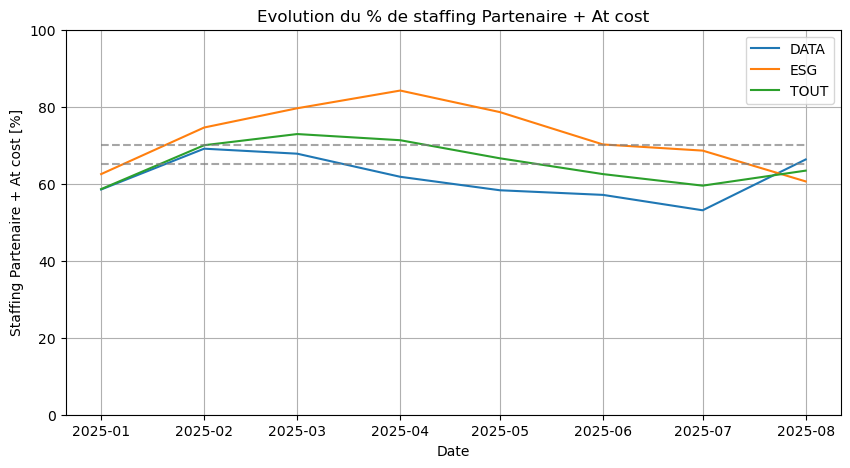

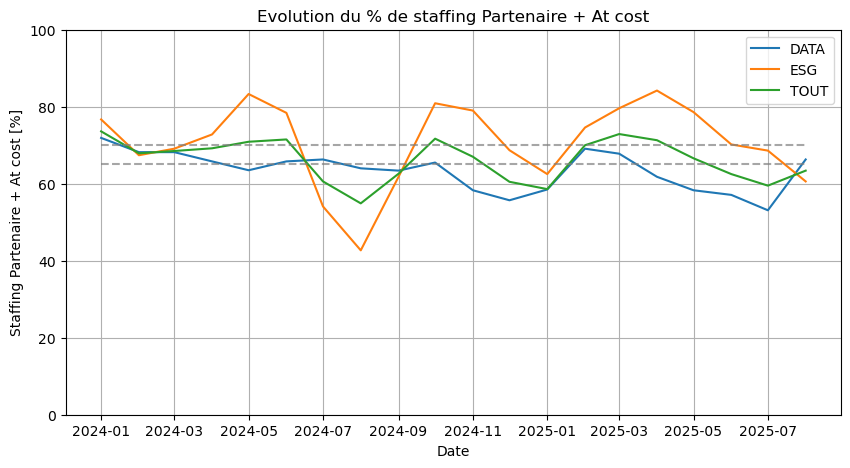

In [20]:
import shutil

path_to_folder_TAF = "P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/"

if True:
    with pd.ExcelWriter(path_to_folder_TAF+"TAF.xlsx", engine='xlsxwriter') as writer:
        TAF_table_grade_current_year.to_excel(writer, sheet_name='TAF par grade - YTD', index=True)
        TAF_table_grade_full.to_excel(writer, sheet_name='TAF par grade - FULL', index=True)
        TAF_table_person_current_year.to_excel(writer, sheet_name='TAF par personne - YTD', index=True)
        TAF_table_person_full.to_excel(writer, sheet_name='TAF par personne - FULL', index=True)
        
    # Création du backup
    today_date = datetime.datetime.today()
    suffix = str(today_date.year)+'-'+str(today_date.month).zfill(2)+'-'+str(today_date.day).zfill(2)
    shutil.copyfile(path_to_folder_TAF+"TAF.xlsx", path_to_folder_TAF+"BACKUPS_TAF/TAF_"+suffix+".xlsx")
    
    
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10,5))

    for lab in ['DATA', 'ESG', 'TOUT']:
        plot_data = TAF_table_grade_current_year.loc[('TOUT', f'Partenaire + At cost ({lab})'), TAF_table_grade_current_year.columns.get_level_values(1) == 'Partenaire'].reset_index()
        plot_data.columns = ['date', '-', '%']
        plot_data = plot_data[['date', '%']]
        plot_data['date'] = pd.to_datetime(plot_data['date'], format='%Y-%m')
        plt.plot(plot_data['date'], plot_data['%'], label=lab)

    plt.plot(plot_data['date'], [65]*len(plot_data['date']), c='gray', alpha=0.7, linestyle='--')    
    plt.plot(plot_data['date'], [70]*len(plot_data['date']), c='gray', alpha=0.7, linestyle='--')  

    plt.title('Evolution du % de staffing Partenaire + At cost')
    plt.xlabel('Date')
    plt.ylabel('Staffing Partenaire + At cost [%]')
    plt.ylim([0, 100])
    plt.grid()
    plt.legend()
    plt.savefig("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/plots/TAF_annuel.png")
    plt.show()



    plt.figure(figsize=(10,5))

    for lab in ['DATA', 'ESG', 'TOUT']:
        plot_data = TAF_table_grade_full.loc[('TOUT', f'Partenaire + At cost ({lab})'), TAF_table_grade_full.columns.get_level_values(1) == 'Partenaire'].reset_index()
        plot_data.columns = ['date', '-', '%']
        plot_data = plot_data[['date', '%']]
        plot_data['date'] = pd.to_datetime(plot_data['date'], format='%Y-%m')
        plt.plot(plot_data['date'], plot_data['%'], label=lab)

    plt.plot(plot_data['date'], [65]*len(plot_data['date']), c='gray', alpha=0.7, linestyle='--')    
    plt.plot(plot_data['date'], [70]*len(plot_data['date']), c='gray', alpha=0.7, linestyle='--')  

    plt.title('Evolution du % de staffing Partenaire + At cost')
    plt.xlabel('Date')
    plt.ylabel('Staffing Partenaire + At cost [%]')
    plt.ylim([0, 100])
    plt.grid()
    plt.legend()
    plt.savefig("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/plots/TAF_complet.png")
    plt.show()

### analyses supp

In [3]:
from scripts.utils_agregation import *
df = aggregate_public_archives("P:/Equipe/Suivi de projet staffing/")[0]

In [4]:
df = pd.read_excel("P:/Equipe/Suivi de projet staffing/Archive des anciens/Suivi_Projet_Agrégé - Anciens.xlsx", engine='calamine')

In [5]:
df

,Qui ?,Projet ?,Date,h
0,khalid.arjdal,_Terminé - Data - Kearney - CFA - AVENANT 0,2024-01-05,31.0
1,khalid.arjdal,ILB - Congés & Arrêts (hors jours fériés),2024-01-05,8.0
2,khalid.arjdal,_Terminé - Data - Kearney - CFA - AVENANT 0,2024-01-12,39.0
3,khalid.arjdal,_Terminé - Data - Kearney - CFA - AVENANT 0,2024-01-19,24.0
4,khalid.arjdal,_Terminé - Data - Kearney - Conseil - AVENANT 0,2024-01-19,15.0
...,...,...,...,...
741,justine.wade,Labs - Préparation présentation d'équipe,2024-12-13,3.0
742,justine.wade,Labs - Réunions internes,2024-12-13,2.0
743,justine.wade,ESG - Arval - Biocarburants Brésil - AVENANT 0,2024-12-20,2.0
744,justine.wade,Labs - Préparation présentation d'équipe,2024-12-20,32.0


In [120]:
df['Qui ?'].unique()

array(['khalid.arjdal', 'yassine.chafai', 'enzo.dalby', 'dreumont.jeremy',
       'sophie.fournier', 'marine.grosmaitre', 'naja.hammad',
       'anne.hamon', 'ilias.nahmed', 'Iker.tardio', 'bertille.tierny',
       'justine.wade'], dtype=object)

In [111]:
#Iker TARDIO sur la période 01/01/2025 au 01/04/2025, 18.41% environ à 6% en remplaçant dans ses données brutes des valeurs "Réunion Interne" par des projets CAA
#Juliette MARTY sur la période 07/04/2025 au 23/05/2025, 17.92% à 6% en faisant la même manip

In [121]:
pers = 'Iker.tardio'
d1, d2 = pd.to_datetime('01/01/2025', format='%d/%m/%Y'), pd.to_datetime('01/04/2025', format='%d/%m/%Y')
df_1 = df[(df['Qui ?']==pers) & (df['Date']>=d1) & (df['Date']<=d2)]
df_1 = df_1[~df_1['Projet ?'].isin(['ILB - Congés & Arrêts (hors jours fériés)', 'ILB - Jour Férié'])]

* calculer le % total.
* voir nb h à supprimer chaque semaine pour arriver au % final
* voir les projets candidats sur chaque semaine.
* répartir les heures sur les projets candidats

In [122]:
current_perc_RI = (100*(df_1[df_1['Projet ?']=='Labs - Réunions internes'].h.sum()/df_1.h.sum())).round(2)
expected_perc = 6
perc_to_remove = current_perc_RI - expected_perc
h_to_remove = perc_to_remove/100 * df_1.h.sum()

current_perc_RI, expected_perc, perc_to_remove, h_to_remove

(np.float64(6.04),
 6,
 np.float64(0.040000000000000036),
 np.float64(0.14560000000000012))

In [123]:
h_to_remove = round(h_to_remove)
h_to_remove

0

In [103]:
# trouver les heures réu par semaine
# pondérer les heures retrancher chaque semaine
# attribuer les heures selon la proportion des h passées sur les sujets CAA de la semaine
# print les modification à effectuer
h_RI_per_week = df_1[df_1['Projet ?']=='Labs - Réunions internes'].groupby('Date').h.sum()
h_RI_per_week = (h_RI_per_week/h_RI_per_week.sum()).sort_index() * h_to_remove
h_RI_per_week

Date
2025-01-17     2.014925
2025-01-31     2.686567
2025-02-07     6.044776
2025-02-14     4.701493
2025-02-21     3.358209
2025-02-28     4.701493
2025-03-07     4.701493
2025-03-14     4.029851
2025-03-21    10.074627
2025-03-28     2.686567
Name: h, dtype: float64

In [104]:
projets_CAA = df_1['Projet ?'].unique()
projets_CAA = [e for e in projets_CAA if 'CAA' in e]
projets_CAA

['ESG - CAA - Alignement & Empreinte carbone - AVENANT 3',
 'ESG - CAA - Alignement & Empreinte carbone - AVENANT 4']

In [105]:
h_CAA_per_week = df_1[df_1['Projet ?'].isin(projets_CAA)].groupby(['Date', 'Projet ?']).h.sum()
h_CAA_per_week

Date        Projet ?                                              
2025-01-17  ESG - CAA - Alignement & Empreinte carbone - AVENANT 3     3
            ESG - CAA - Alignement & Empreinte carbone - AVENANT 4     6
2025-01-31  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4     8
2025-02-07  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4     8
2025-02-14  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4    14
2025-02-21  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4    12
2025-02-28  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4     9
2025-03-07  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4    16
2025-03-14  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4    14
2025-03-21  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4    14
2025-03-28  ESG - CAA - Alignement & Empreinte carbone - AVENANT 4     6
Name: h, dtype: int64

In [106]:
cum_errors = 0

for date in h_RI_per_week.index:
    h_to_remove = h_RI_per_week[date]
    h_CAA = h_CAA_per_week[date]/h_CAA_per_week[date].sum()
    projets_ = h_CAA.index
    if len(projets_)<2:
        h_to_remove_app = np.round(2*h_to_remove)/2
        error = h_to_remove - h_to_remove_app
        cum_errors += error
        print(date, projets_[0], h_to_remove_app, f"[{error}]")
    else:
        print(date, h_to_remove)
        for projet_ in projets_:
            h_to_remove_app = np.round(2*h_CAA[projet_]*h_to_remove)/2
            error = h_CAA[projet_]*h_to_remove - h_to_remove_app
            cum_errors += error
            print(projet_, h_to_remove_app, f"[{error}]")
    print('\n')
    
print(cum_errors)

2025-01-17 00:00:00 2.014925373134328
ESG - CAA - Alignement & Empreinte carbone - AVENANT 3 0.5 [0.17164179104477606]
ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 1.5 [-0.15671641791044788]


2025-01-31 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 2.5 [0.18656716417910424]


2025-02-07 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 6.0 [0.04477611940298498]


2025-02-14 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 4.5 [0.20149253731343286]


2025-02-21 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 3.5 [-0.1417910447761197]


2025-02-28 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 4.5 [0.20149253731343286]


2025-03-07 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 4.5 [0.20149253731343286]


2025-03-14 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 4.0 [0.02985074626865636]


2025-03-21 00:00:00 ESG - CAA - Alignement & Empreinte carbone - AVENANT 4 1

### Modification BDD (rétropropagation)

In [3]:
from scripts.utils_BDD import load_BDD
vision_personne_current, vision_contrat_current, utils_personne_current, utils_contrat_current = load_BDD("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/")

In [10]:
import pandas as pd
status_information = pd.read_excel("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/" + "ILB_Projects.xlsx", sheet_name="STATUS_INFORMATIONS", engine='calamine')
status_information = status_information[~ status_information["Prenom nom"].isna()]
status_information.replace({"Prenom nom": lambda x: x.lower()}, inplace=True)

In [11]:
status_information['Taux horaire (€)'].unique()

array([49.35897436, 23.28571429, 59.23076923, 84.61538462, 59.74358974])

In [14]:
status_information

,Prenom nom,Grade,Taux horaire (€),Mask,Data Lab,ESG Lab,Check
0,adel.medjabri,Junior,49.358974,Non,0.0,1.0,1
1,adrien.ferrand,Junior,49.358974,Non,0.0,1.0,1
2,ana.vallejo,Junior,49.358974,Non,0.0,1.0,1
3,anne.hamon,Stagiaire,23.285714,Oui,0.0,1.0,1
4,bertille.tierny,Stagiaire,23.285714,Oui,1.0,0.0,1
5,enzo.dalby,Junior,49.358974,Non,1.0,0.0,1
6,gabriel.levy,Senior,59.230769,Non,0.0,1.0,1
7,gabriel.plantier,Senior,59.230769,Oui,0.0,1.0,1
8,ghassen.benhassine,Senior,59.230769,Non,1.0,0.0,1
9,hamada.saleh,Junior,49.358974,Non,1.0,0.0,1


In [23]:
status_information.iloc[6]['Taux horaire (€)']

np.float64(59.23076923076923)

In [16]:
utils_personne_current.iloc[8].taux_horaire

[112, Timestamp('2025-02-01 00:00:00'), 147]

In [ ]:
def change_taux_horaire(elt, new_v):
    if len(elt)==1:
        return elt[:-1] + f", Timestamp('2025-01-01 00:00:00'), {new_v}]"

def read_utils_format_from_str(elt):
        elt_to_list = ast.literal_eval(elt)
        for i in range(1,len(elt_to_list),2):
            elt_to_list[i] = pd.to_datetime(elt_to_list[i])
        return elt_to_list
    
change_taux_horaire([147], 56)

"[147, Timestamp('2025-01-01 00:00:00'), 56]"

# ANALYSES ANNEXES

In [3]:
from scripts.utils_BDD import load_BDD
from scripts.utils_analyses_annexes import get_details_about_someone, checking_the_good_labsiens

vision_personne_current, vision_contrat_current, utils_personne_current, utils_contrat_current = load_BDD("P:/Equipe/Suivi de projet staffing/Données agrégées/Liens/")

In [4]:
print(vision_personne_current.shape)

(20432, 33)


In [5]:
get_details_about_someone(vision_personne_current, "martin.recroix", 2025, 8)


,h,%
root_name,,
Data - CGDD - Analyse financière du label Greenfin - AVENANT 0,125.5,77.0
Data - Challenge Data - Gestion Challenge,13.0,8.0
ILB - Congés & Arrêts (hors jours fériés),8.0,4.9
ILB - Jour Férié,7.0,4.3
Kanban - Suivi budgétaire projets,3.0,1.8
Labs - Prospection,0.5,0.3
Labs - Réunions internes,5.0,3.1
Labs - Tâches interne (autres),1.0,0.6


Removed: adrien.ferrand, anne.hamon, bertille.tierny, caroline.nguyen, enzo.dalby, gabriel.levy, gabriel.plantier, iker.tardio, ilias.nahmed, jeremy.dreumont, joao.serta, justine.wade, kelly.bourbon, khalid.arjdal, louis.boulanger, luis.campos, marine.grosmaitre, naja.hammad, nestor.toroman, pauline.aumard, philomene.cholet, sophie.fournier, yassine.chafai, youssra.bendjebbar


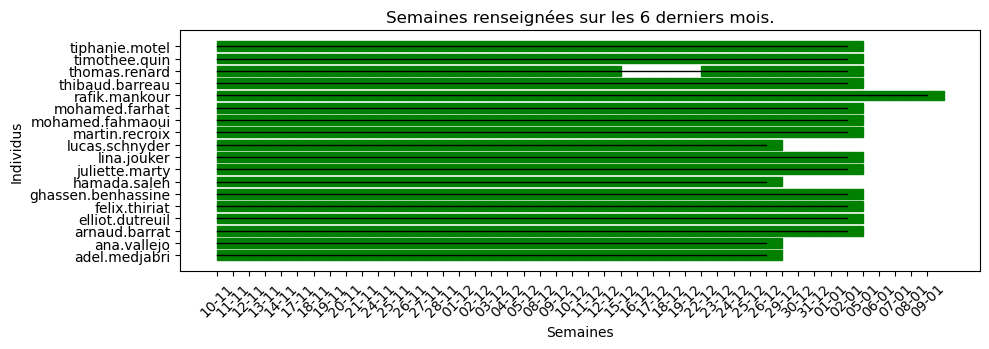

In [6]:
checking_the_good_labsiens(vision_personne_current, k_months_ago=2)

In [ ]:
215_000 * 4 / (24*3600)

9.953703703703704

In [31]:
a = 'Data - PARC - Sustainable finance research cartography'

In [32]:
vision_personne_current[vision_personne_current.root_name==a]

,prenom_nom,root_name,date,h,Entreprise,Type,Sujet,finished_tag,grade,taux_horaire,...,h_ESG Lab,coût_ESG Lab,h_Senior,coût_Senior,h_Junior,coût_Junior,h_Stagiaire,coût_Stagiaire,h_Responsable,coût_Responsable
3795,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-03-07,1.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,1.0,147.0,0.0,0,0.0,0,0.0,0
3804,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-03-14,1.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,1.0,147.0,0.0,0,0.0,0,0.0,0
3812,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-03-21,1.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,1.0,147.0,0.0,0,0.0,0,0.0,0
3836,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-04-11,5.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,5.0,735.0,0.0,0,0.0,0,0.0,0
3846,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-04-18,1.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,1.0,147.0,0.0,0,0.0,0,0.0,0
3855,thibaud.barreau,Data - PARC - Sustainable finance research car...,2025-04-25,1.0,PARC,NaN,NaN,False,Senior,147,...,0.0,0.0,1.0,147.0,0.0,0,0.0,0,0.0,0
4592,mohamed.fahmaoui,Data - PARC - Sustainable finance research car...,2025-02-28,8.0,PARC,NaN,NaN,False,Junior,112,...,0.0,0.0,0.0,0.0,8.0,896,0.0,0,0.0,0
4599,mohamed.fahmaoui,Data - PARC - Sustainable finance research car...,2025-03-07,10.0,PARC,NaN,NaN,False,Junior,112,...,0.0,0.0,0.0,0.0,10.0,1120,0.0,0,0.0,0
4605,mohamed.fahmaoui,Data - PARC - Sustainable finance research car...,2025-03-14,4.0,PARC,NaN,NaN,False,Junior,112,...,0.0,0.0,0.0,0.0,4.0,448,0.0,0,0.0,0
4612,mohamed.fahmaoui,Data - PARC - Sustainable finance research car...,2025-03-21,6.0,PARC,NaN,NaN,False,Junior,112,...,0.0,0.0,0.0,0.0,6.0,672,0.0,0,0.0,0


### TEST MODIFICATION OUTIL : passage à la granularité journalière

In [92]:
def explode_weekly_df(df, id_cols=['id'], date_col='date'):
    """
    Transforme un DataFrame avec des colonnes 'lundi' à 'vendredi' en un format long,
    avec une ligne par jour et une date calculée.

    Args:
        df (pd.DataFrame): DataFrame d'entrée.
        id_cols (str): Noms des colonnes identifiantes.
        date_col (str): Colonne contenant la date du vendredi de la semaine.

    Returns:
        pd.DataFrame: DataFrame transformé avec colonnes: id, date, h (valeur), jour (nom du jour).
    """

    day_cols=['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi']
    
    # Mapping pour reculer à partir de vendredi
    day_offsets = {
        'Lundi': -4,
        'Mardi': -3,
        'Mercredi': -2,
        'Jeudi': -1,
        'Vendredi': 0
    }

    # Transformation en long format
    df_long = df.melt(id_vars=id_cols+[date_col], value_vars=day_cols,
                      var_name='jour', value_name='h')

    # Calcul de la vraie date pour chaque jour
    df_long[date_col] = pd.to_datetime(df_long[date_col]) + df_long['jour'].map(lambda d: timedelta(days=day_offsets[d]))

    # Réorganiser les colonnes (facultatif)
    df_long = df_long[df_long['h']>0][id_cols+[date_col, 'jour', 'h']]
    return df_long.sort_values(by=date_col)


# Reading every excel and aggregating in a single df
def aggregate_public_archives(folder_path):
    
    if folder_path[-1]!='/': folder_path += '/'
    
    file_names = []
    for (dirpath, dirnames, filenames) in os.walk(folder_path):
        file_names.extend(filenames)
        break
    
    df_list = []
    
    problematic_files = []
    for file in file_names:
        try:
            df = pd.read_excel(folder_path + file, sheet_name="Archive", engine='calamine', date_format={'Date': '%Y-%m-%d'})
            df = explode_weekly_df(df, id_cols=['Qui ?', 'Projet ?'], date_col='Date')
            df_list.append(df)
        except:
            problematic_files.append(file)
    
    aggregated_public_archives = pd.concat(df_list, ignore_index=True)
    
    return aggregated_public_archives, problematic_files


df = aggregate_public_archives("P:/Equipe/Suivi de projet staffing/")

C:\Users\martin.recroix\AppData\Local\Temp\ipykernel_492\799956467.py:31: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  df_long[date_col] = pd.to_datetime(df_long[date_col]) + df_long['jour'].map(lambda d: timedelta(days=day_offsets[d]))
C:\Users\martin.recroix\AppData\Local\Temp\ipykernel_492\799956467.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggregated_public_archives = pd.concat(df_list, ignore_index=True)


In [94]:
df[0].tail(50)

,Qui ?,Projet ?,Date,jour,h
9172,ana.vallejo,ESG - FFEA - CSRD et Expertise Auto - AVENANT 0,2025-09-09,Mardi,1.0
9173,ana.vallejo,ESG - CAA - Alignement & Empreinte carbone - A...,2025-09-09,Mardi,7.0
9174,ana.vallejo,ESG - CAA - Alignement & Empreinte carbone - A...,2025-09-10,Mercredi,8.0
9175,ana.vallejo,ESG - FFEA - CSRD et Expertise Auto - AVENANT 0,2025-09-11,Jeudi,1.0
9176,ana.vallejo,ESG - CAA - Alignement & Empreinte carbone - A...,2025-09-11,Jeudi,7.0
9177,ana.vallejo,ESG - FFEA - CSRD et Expertise Auto - AVENANT 0,2025-09-12,Vendredi,2.0
9178,ana.vallejo,ESG - CAA - Alignement & Empreinte carbone - A...,2025-09-12,Vendredi,5.0
9179,ana.vallejo,ESG - CAA - Alignement & Empreinte carbone - A...,2025-09-15,Lundi,7.0
9180,ana.vallejo,ESG - FFEA - CSRD et Expertise Auto - AVENANT 0,2025-09-15,Lundi,1.0
9181,ana.vallejo,Labs - Préparation présentation d'équipe,2025-09-16,Mardi,2.0


In [40]:
import os

def get_files(folder_path):
    
    if folder_path[-1]!='/': folder_path += '/'
    
    file_names = []
    for (dirpath, dirnames, filenames) in os.walk(folder_path):
        file_names.extend(filenames)
        break
    
    return file_names
    
get_files("P:/Equipe/Suivi de projet staffing/")

['Suivi_projet_barrat_arnaud.xlsm',
 'Suivi_projet_barreau_thibaud.xlsm',
 'Suivi_projet_ben_hassine_ghassen.xlsm',
 'Suivi_projet_bourbon_kelly.xlsm',
 'Suivi_projet_dutreuil_elliot.xlsm',
 'Suivi_projet_fahmaoui_mohamed.xlsm',
 'Suivi_Projet_farhat_mohamed.xlsm',
 'Suivi_projet_jouker_lina.xlsm',
 'Suivi_Projet_mankour_rafik.xlsm',
 'Suivi_projet_marty_juliette.xlsm',
 'Suivi_projet_medjabri_adel.xlsm',
 'Suivi_projet_motel_tiphanie.xlsm',
 'Suivi_projet_nguyen_caroline.xlsm',
 'Suivi_projet_quin_timothee.xlsm',
 'Suivi_projet_recroix_martin.xlsm',
 'Suivi_projet_renard_thomas.xlsm',
 'Suivi_projet_saleh_hamada.xlsm',
 'Suivi_projet_schnyder_lucas.xlsm',
 'Suivi_projet_serta_joao.xlsm',
 'Suivi_projet_thiriat_felix.xlsm',
 'Suivi_projet_toroman_nestor.xlsm',
 'Suivi_projet_vallejo_ana.xlsm',
 'Suivi_projet_vandeputte_tristan.xlsm']

In [77]:
df = pd.read_excel("P:/Equipe/Suivi de projet staffing/Suivi_projet_recroix_martin.xlsm", sheet_name="Archive", engine='calamine', date_parser=['Date'])

C:\Users\martin.recroix\AppData\Local\Temp\ipykernel_492\2558377056.py:1: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  df = pd.read_excel("P:/Equipe/Suivi de projet staffing/Suivi_projet_recroix_martin.xlsm", sheet_name="Archive", engine='calamine', date_parser=['Date'])


In [78]:
df

,Qui ?,Projet ?,Date,Lundi,Mardi,Mercredi,Jeudi,Vendredi
0,martin.recroix,Labs - Réunions internes,2024-11-22,0.0,1.0,0.0,0.0,0.0
1,martin.recroix,Labs - Préparation présentation d'équipe,2024-11-22,2.0,4.0,1.5,2.0,7.0
2,martin.recroix,Kanban - _Terminé - Suivi budgétaire projets,2024-11-22,NaN,NaN,1.5,4.0,NaN
3,martin.recroix,Data - Labs - Challenge Data - Beta Testing,2024-11-22,NaN,NaN,1.0,2.0,NaN
4,martin.recroix,_Terminé - Data - BNPP PF - Data RCS - AVENANT 6,2024-11-22,6.0,3.0,4.0,NaN,NaN
...,...,...,...,...,...,...,...,...
269,martin.recroix,ILB - IT,2025-10-03,0.0,0.0,0.0,1.0,0.0
270,martin.recroix,Labs - Préparation présentation d'équipe,2025-10-03,3.0,3.0,3.0,4.0,2.0
271,martin.recroix,Kanban - _Terminé - Suivi budgétaire projets,2025-10-03,1.0,0.0,2.0,0.0,0.0
272,martin.recroix,Data - Challenge Data - Gestion Challenge,2025-10-03,1.0,1.0,0.0,0.0,2.0


In [87]:
import pandas as pd
from datetime import timedelta

def explode_weekly_df(df, id_col='id', date_col='date'):
    """
    Transforme un DataFrame avec des colonnes 'lundi' à 'vendredi' en un format long,
    avec une ligne par jour et une date calculée.

    Args:
        df (pd.DataFrame): DataFrame d'entrée.
        id_col (str): Nom de la colonne identifiant.
        date_col (str): Colonne contenant la date du vendredi de la semaine.

    Returns:
        pd.DataFrame: DataFrame transformé avec colonnes: id, date, h (valeur), jour (nom du jour).
    """

    day_cols=['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi']
    
    # Mapping pour reculer à partir de vendredi
    day_offsets = {
        'Lundi': -4,
        'Mardi': -3,
        'Mercredi': -2,
        'Jeudi': -1,
        'Vendredi': 0
    }

    # Transformation en long format
    df_long = df.melt(id_vars=[id_col, date_col], value_vars=day_cols,
                      var_name='jour', value_name='h')

    # Calcul de la vraie date pour chaque jour
    df_long[date_col] = pd.to_datetime(df_long[date_col]) + df_long['jour'].map(lambda d: timedelta(days=day_offsets[d]))

    # Réorganiser les colonnes (facultatif)
    df_long = df_long[df_long['h']>0][[id_col, date_col, 'jour', 'h']]
    return df_long.sort_values(by=date_col)


explode_weekly_df(df, id_col='Projet ?', date_col='Date').tail(20)

,Projet ?,Date,jour,h
1360,Labs - Préparation présentation d'équipe,2025-09-26,Vendredi,1.0
1362,Data - Challenge Data - Gestion Challenge,2025-09-26,Vendredi,1.5
1363,Data - CGDD - Analyse financière du label Gree...,2025-09-26,Vendredi,3.5
272,Data - Challenge Data - Gestion Challenge,2025-09-29,Lundi,1.0
273,Data - CGDD - Analyse financière du label Gree...,2025-09-29,Lundi,3.0
270,Labs - Préparation présentation d'équipe,2025-09-29,Lundi,3.0
271,Kanban - _Terminé - Suivi budgétaire projets,2025-09-29,Lundi,1.0
547,Data - CGDD - Analyse financière du label Gree...,2025-09-30,Mardi,3.0
546,Data - Challenge Data - Gestion Challenge,2025-09-30,Mardi,1.0
544,Labs - Préparation présentation d'équipe,2025-09-30,Mardi,3.0


In [ ]:
import pandas as pd
from datetime import timedelta

def explode_weekly_df(df, id_cols=['id'], date_col='date'):
    """
    Transforme un DataFrame avec des colonnes 'lundi' à 'vendredi' en un format long,
    avec une ligne par jour et une date calculée.

    Args:
        df (pd.DataFrame): DataFrame d'entrée.
        id_cols (str): Noms des colonnes identifiantes.
        date_col (str): Colonne contenant la date du vendredi de la semaine.

    Returns:
        pd.DataFrame: DataFrame transformé avec colonnes: id, date, h (valeur), jour (nom du jour).
    """

    day_cols=['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi']
    
    # Mapping pour reculer à partir de vendredi
    day_offsets = {
        'Lundi': -4,
        'Mardi': -3,
        'Mercredi': -2,
        'Jeudi': -1,
        'Vendredi': 0
    }

    # Transformation en long format
    df_long = df.melt(id_vars=id_cols+[date_col], value_vars=day_cols,
                      var_name='jour', value_name='h')

    # Calcul de la vraie date pour chaque jour
    df_long[date_col] = pd.to_datetime(df_long[date_col]) + df_long['jour'].map(lambda d: timedelta(days=day_offsets[d]))

    # Réorganiser les colonnes (facultatif)
    df_long = df_long[df_long['h']>0][id_cols+[date_col, 'jour', 'h']]
    return df_long.sort_values(by=date_col)


explode_weekly_df(df, id_cols=['Qui ?', 'Projet ?'], date_col='Date').tail(20)

,Qui ?,Projet ?,Date,jour,h
1360,martin.recroix,Labs - Préparation présentation d'équipe,2025-09-26,Vendredi,1.0
1362,martin.recroix,Data - Challenge Data - Gestion Challenge,2025-09-26,Vendredi,1.5
1363,martin.recroix,Data - CGDD - Analyse financière du label Gree...,2025-09-26,Vendredi,3.5
272,martin.recroix,Data - Challenge Data - Gestion Challenge,2025-09-29,Lundi,1.0
273,martin.recroix,Data - CGDD - Analyse financière du label Gree...,2025-09-29,Lundi,3.0
270,martin.recroix,Labs - Préparation présentation d'équipe,2025-09-29,Lundi,3.0
271,martin.recroix,Kanban - _Terminé - Suivi budgétaire projets,2025-09-29,Lundi,1.0
547,martin.recroix,Data - CGDD - Analyse financière du label Gree...,2025-09-30,Mardi,3.0
546,martin.recroix,Data - Challenge Data - Gestion Challenge,2025-09-30,Mardi,1.0
544,martin.recroix,Labs - Préparation présentation d'équipe,2025-09-30,Mardi,3.0
